In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/maryland_energy_clean.csv')

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)

Dataset shape: (1276, 4)

First few rows:
  State  Year  Value                   Metric
0    MD  1970   2.31  Avg Price - Residential
1    MD  1971   2.53  Avg Price - Residential
2    MD  1972   2.69  Avg Price - Residential
3    MD  1973   3.04  Avg Price - Residential
4    MD  1974   3.95  Avg Price - Residential

Data types:
State      object
Year        int64
Value     float64
Metric     object
dtype: object


In [2]:
print("Year range:", df['Year'].min(), "-", df['Year'].max())
print("Number of metrics:", df['Metric'].nunique())
print("\nMetrics available:")
print(df['Metric'].unique())

Year range: 1960 - 2024
Number of metrics: 24

Metrics available:
['Avg Price - Residential' 'Avg Price - Commercial'
 'Avg Price - Industrial' 'Avg Price - Transportation' 'Avg Price - Total'
 'Price - Petroleum' 'Expenditure - Petroleum' 'Price - Natural Gas'
 'Expenditure - Natural Gas' 'Price - Coal' 'Expenditure - Coal'
 'Price - Electricity' 'Expenditure - Electricity' 'Price - Other'
 'Expenditure - Other' 'Expenditure Per Capita - Other'
 'Total Consumption' 'Real GDP' 'Energy per GDP'
 'Expenditure - Residential' 'Expenditure - Commercial'
 'Expenditure - Industrial' 'Expenditure - Transportation'
 'Expenditure - Total']


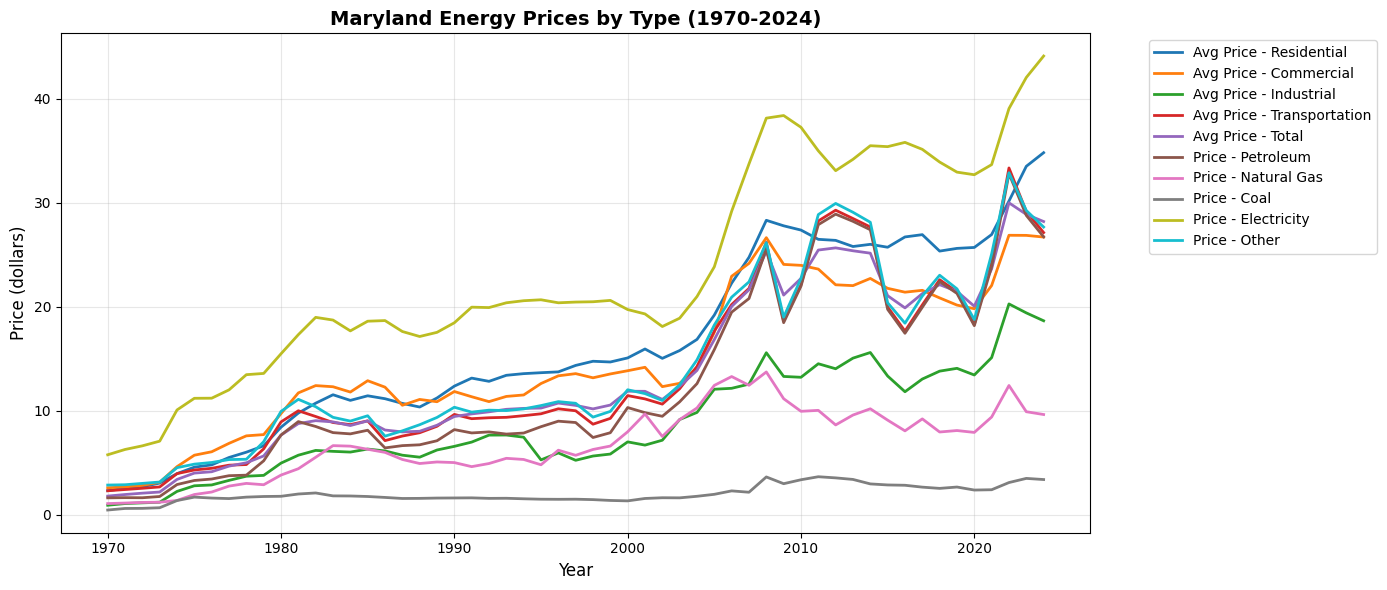

In [ ]:
price_metrics = df[df['Metric'].str.contains('Price', case=False)]

plt.figure(figsize=(14, 6))
for metric in price_metrics['Metric'].unique():
    data = price_metrics[price_metrics['Metric'] == metric]
    plt.plot(data['Year'], data['Value'], label=metric, linewidth=2)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Price (dollars)', fontsize=12)
plt.title('Maryland Energy Prices by Type (1970-2024)', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

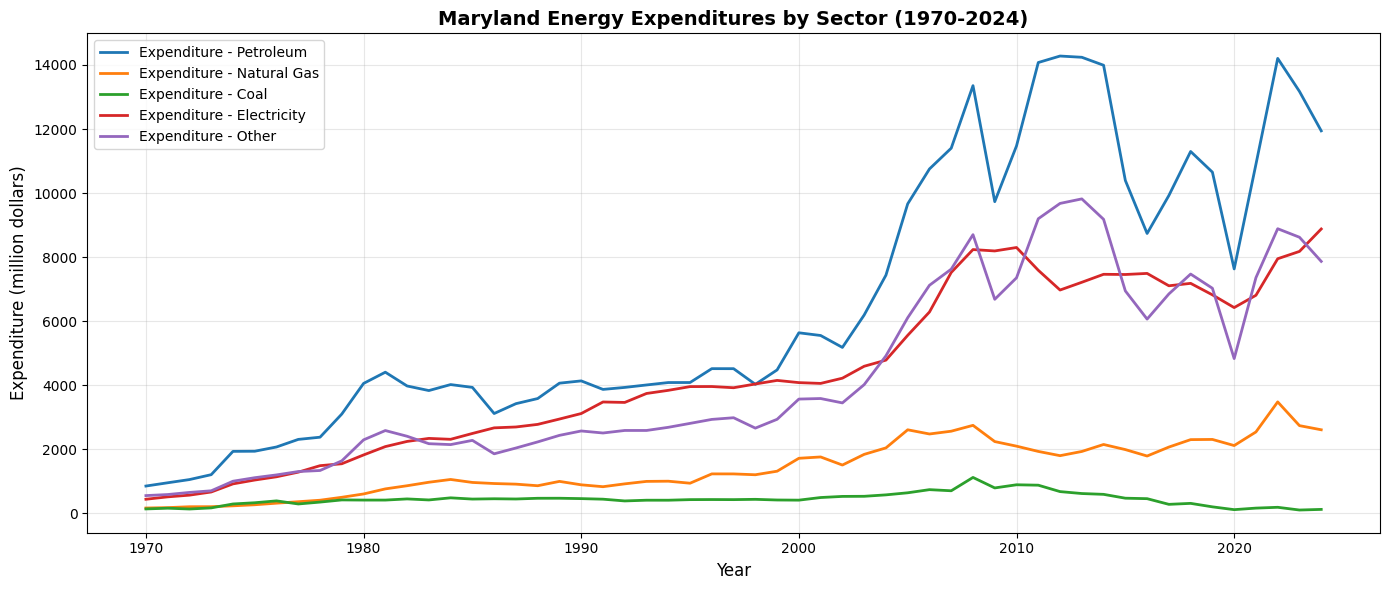

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/maryland_energy_clean.csv')

expend_metrics = df[df['Metric'].str.contains('Expenditure', case=False) & ~df['Metric'].str.contains('Per Capita')]

plt.figure(figsize=(14, 6))
for metric in expend_metrics['Metric'].unique()[:5]:  # Top 5
    data = expend_metrics[expend_metrics['Metric'] == metric]
    plt.plot(data['Year'], data['Value'], label=metric, linewidth=2)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Expenditure (million dollars)', fontsize=12)
plt.title('Maryland Energy Expenditures by Sector (1970-2024)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
latest_year = df['Year'].max()
latest_data = df[df['Year'] == latest_year].sort_values('Value', ascending=False)

print(f"\n=== Energy Metrics for Maryland in {latest_year} ===\n")
print(latest_data[['Metric', 'Value']].to_string(index=False))


=== Energy Metrics for Maryland in 2024 ===

                        Metric      Value
             Total Consumption 1201574.00
                      Real GDP  433105.90
           Expenditure - Total   23067.90
       Expenditure - Petroleum   11942.70
  Expenditure - Transportation   10358.70
     Expenditure - Electricity    8879.20
           Expenditure - Other    7867.70
     Expenditure - Residential    6650.00
      Expenditure - Commercial    4915.10
     Expenditure - Natural Gas    2611.00
Expenditure Per Capita - Other    1259.80
      Expenditure - Industrial    1144.10
            Expenditure - Coal     125.30
           Price - Electricity      44.09
       Avg Price - Residential      34.80
             Avg Price - Total      28.18
                 Price - Other      27.65
    Avg Price - Transportation      27.12
             Price - Petroleum      26.71
        Avg Price - Commercial      26.69
        Avg Price - Industrial      18.64
           Price - Natural Gas